# Practice Lab: Neural Network 1

**College:** MIT Academy of Engineering, Alandi, Pune  
**Class:** T.Y. B.Tech  
**Department:** CSE AIML  
**Course:** Generative AI Lab  
**Practice Lab:** Neural Network 1  

**Name:** Chirag Nagawade  
**PRN Number:** 202502110009  
**Batch:** A3  
**Date of Submission:** 15/08/2026  


## 1. Objective

- To implement a feedforward neural network from scratch.
- To implement forward propagation.
- To implement backpropagation.
- To implement gradient descent.
- To train the network for classification.

## 2. Problem Definition

### Dataset

The Iris dataset is used for training and testing the neural network. It is a well-known dataset containing **150 samples** of Iris flowers. Each sample has **four input features**:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

The dataset contains three target classes:

- Setosa
- Versicolor
- Virginica

### Task

The task is to develop a **multi-class classification model** using a feedforward neural network implemented from scratch in Python.

The neural network will learn from the four flower measurements and classify each Iris flower into one of the three species.

Load the Iris Dataset

In [55]:
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# Store features and target
X = iris.data
y = iris.target

# Display basic information
print("Dataset Shape:", X.shape)
print("Target Shape:", y.shape)
print("Feature Names:", iris.feature_names)
print("Target Names:", iris.target_names)

Dataset Shape: (150, 4)
Target Shape: (150,)
Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Names: ['setosa' 'versicolor' 'virginica']


Display the Dataset

In [56]:
# Display the first 5 samples
print("First 5 samples:")
print(X[:5])

print("\nFirst 5 target labels:")
print(y[:5])

First 5 samples:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

First 5 target labels:
[0 0 0 0 0]


Check for Missing Values

In [57]:
import numpy as np

print("Missing values in X:", np.isnan(X).sum())
print("Missing values in y:", np.isnan(y).sum())

Missing values in X: 0
Missing values in y: 0


Data Preprocessing

## 3. Data Preprocessing

The dataset is divided into training and testing sets. The training data is used to train the neural network, while the testing data is used to evaluate its performance on unseen samples.

In [58]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)


Feature Scaling

In [59]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit on training data and transform training data
X_train = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test = scaler.transform(X_test)

print("First 5 scaled training samples:")
print(X_train[:5])

First 5 scaled training samples:
[[-1.72156775 -0.33210111 -1.34572231 -1.32327558]
 [-1.12449223 -1.22765467  0.41450518  0.6517626 ]
 [ 1.14439475 -0.5559895   0.58484978  0.25675496]
 [-1.12449223  0.11567567 -1.28894078 -1.45494479]
 [-0.40800161 -1.22765467  0.13059752  0.12508575]]


In [60]:
import numpy as np

# Function for one-hot encoding
def one_hot_encode(y, num_classes):
    one_hot = np.zeros((len(y), num_classes))
    one_hot[np.arange(len(y)), y] = 1
    return one_hot

# Convert target labels to one-hot encoded format
y_train_onehot = one_hot_encode(y_train, 3)
y_test_onehot = one_hot_encode(y_test, 3)

print("First 5 encoded training labels:")
print(y_train_onehot[:5])

First 5 encoded training labels:
[[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]]


## 4. Neural Network Architecture

The neural network consists of an input layer, one hidden layer, and an output layer.

- **Input Layer:** 4 neurons corresponding to the four Iris features.
- **Hidden Layer:** 8 neurons using the ReLU activation function.
- **Output Layer:** 3 neurons corresponding to the three Iris classes.
- **Output Activation:** Softmax is used to generate class probabilities.

The overall architecture is:

**4 → 8 → 3**

The network is trained using backpropagation and gradient descent.

Initialize Weights and Biases

In [61]:
# Set random seed for reproducible results
np.random.seed(42)

# Number of neurons in each layer
input_size = 4
hidden_size = 8
output_size = 3

# Initialize weights and biases
W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

# Display shapes
print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

W1 shape: (4, 8)
b1 shape: (1, 8)
W2 shape: (8, 3)
b2 shape: (1, 3)


## 5. Activation Functions

### ReLU Activation Function

The Rectified Linear Unit (ReLU) is used in the hidden layer. It converts negative values to zero while keeping positive values unchanged.

**ReLU(x) = max(0, x)**

### Softmax Activation Function

The Softmax function is used in the output layer for multi-class classification. It converts the output values into probabilities whose sum is equal to 1.

### ReLU Derivative

The derivative of ReLU is required during backpropagation to calculate the gradients.


In [62]:
# ReLU activation function
def relu(x):
    return np.maximum(0, x)

In [63]:
# Derivative of ReLU
def relu_derivative(x):
    return (x > 0).astype(float)

In [64]:
# Softmax activation function
def softmax(x):
    # Subtract maximum value for numerical stability
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))

    # Convert values into probabilities
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

In [65]:
# Test Softmax
test_values = np.array([[1.0, 2.0, 3.0]])

probabilities = softmax(test_values)

print("Softmax probabilities:", probabilities)
print("Sum of probabilities:", np.sum(probabilities))

Softmax probabilities: [[0.09003057 0.24472847 0.66524096]]
Sum of probabilities: 0.9999999999999999


## 6. Forward Propagation

Forward propagation is the process of passing input data through the neural network to calculate the predicted output.

The calculations are performed in two stages:

### Hidden Layer

**Z1 = XW1 + b1**

**A1 = ReLU(Z1)**

### Output Layer

**Z2 = A1W2 + b2**

**A2 = Softmax(Z2)**

Here, `A2` represents the predicted probability for each of the three Iris classes.

In [66]:
# Forward propagation function
def forward_pass(X, W1, b1, W2, b2):

    # Hidden layer calculation
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    # Output layer calculation
    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)

    return Z1, A1, Z2, A2

In [67]:
# Perform forward propagation on training data
Z1, A1, Z2, A2 = forward_pass(
    X_train,
    W1,
    b1,
    W2,
    b2
)

# Display shapes of intermediate outputs
print("Z1 shape:", Z1.shape)
print("A1 shape:", A1.shape)
print("Z2 shape:", Z2.shape)
print("A2 shape:", A2.shape)

Z1 shape: (120, 8)
A1 shape: (120, 8)
Z2 shape: (120, 3)
A2 shape: (120, 3)


In [68]:
# Display predictions for the first 5 training samples
print("Predicted probabilities:")
print(A2[:5])

# Check that each row sums to 1
print("\nSum of probabilities for first 5 samples:")
print(np.sum(A2[:5], axis=1))

Predicted probabilities:
[[0.3333332  0.3333346  0.33333219]
 [0.33341751 0.33337294 0.33320955]
 [0.33339815 0.33333391 0.33326794]
 [0.33328417 0.33331935 0.33339647]
 [0.3334487  0.33336088 0.33319042]]

Sum of probabilities for first 5 samples:
[1. 1. 1. 1. 1.]


## 7. Loss Function

The Categorical Cross-Entropy loss function is used to measure the difference between the actual class labels and the predicted class probabilities.

The loss function is given by:

**Loss = -1/N × Σ y × log(y_pred)**

where:

- `N` is the number of samples.
- `y` is the actual one-hot encoded label.
- `y_pred` is the predicted probability from the Softmax output.

A lower loss value indicates that the predictions are closer to the actual labels.

In [69]:
# Categorical Cross-Entropy loss function
def cross_entropy_loss(y_true, y_pred):

    # Small value to avoid log(0)
    epsilon = 1e-8

    # Prevent probabilities from becoming exactly 0 or 1
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    # Calculate cross-entropy loss
    loss = -np.mean(
        np.sum(y_true * np.log(y_pred), axis=1)
    )

    return loss

In [70]:
# Calculate the initial loss
loss = cross_entropy_loss(y_train_onehot, A2)

print("Initial Loss:", loss)

Initial Loss: 1.0986883063364372


## 8. Backpropagation

Backpropagation is used to calculate the gradients of the loss function with respect to the weights and biases of the neural network.

The gradients are calculated from the output layer toward the input layer.

For the Softmax activation combined with Cross-Entropy loss:

**dZ2 = A2 - Y**

The gradients for the output layer are:

**dW2 = A1ᵀ × dZ2**

**db2 = ΣdZ2**

For the hidden layer:

**dA1 = dZ2 × W2ᵀ**

**dZ1 = dA1 × ReLU'(Z1)**

The gradients for the first layer are:

**dW1 = Xᵀ × dZ1**

**db1 = ΣdZ1**

These gradients will be used by gradient descent to update the weights and biases.

In [71]:
# Backpropagation function
def backward_pass(X, y_true, Z1, A1, A2, W2):

    # Number of training samples
    m = X.shape[0]

    # Output layer gradient
    dZ2 = A2 - y_true

    # Gradients for second layer weights and bias
    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # Gradient flowing back to hidden layer
    dA1 = np.dot(dZ2, W2.T)

    # Apply derivative of ReLU
    dZ1 = dA1 * relu_derivative(Z1)

    # Gradients for first layer weights and bias
    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2

In [72]:
# Calculate gradients using the current forward-pass results
dW1, db1, dW2, db2 = backward_pass(
    X_train,
    y_train_onehot,
    Z1,
    A1,
    A2,
    W2
)

# Display gradient shapes
print("dW1 shape:", dW1.shape)
print("db1 shape:", db1.shape)
print("dW2 shape:", dW2.shape)
print("db2 shape:", db2.shape)

dW1 shape: (4, 8)
db1 shape: (1, 8)
dW2 shape: (8, 3)
db2 shape: (1, 3)


## 9. Gradient Descent and Model Training

Gradient Descent is used to minimize the loss function by updating the weights and biases in the direction that reduces the error.

The parameters are updated using the following equation:

**Parameter = Parameter - Learning Rate × Gradient**

The training process is repeated for multiple epochs. In each epoch, the network performs forward propagation, calculates the loss, performs backpropagation, and updates the weights and biases.

In [73]:
# Training parameters
learning_rate = 0.01
epochs = 1000

# Store loss values for visualization
loss_history = []

In [74]:
# Train the neural network
for epoch in range(epochs):

    # Forward propagation
    Z1, A1, Z2, A2 = forward_pass(
        X_train,
        W1,
        b1,
        W2,
        b2
    )

    # Calculate loss
    loss = cross_entropy_loss(
        y_train_onehot,
        A2
    )

    # Store loss
    loss_history.append(loss)

    # Backpropagation
    dW1, db1, dW2, db2 = backward_pass(
        X_train,
        y_train_onehot,
        Z1,
        A1,
        A2,
        W2
    )

    # Update weights and biases using Gradient Descent
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    # Display loss every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss:.4f}")

Epoch 100/1000, Loss: 1.0985
Epoch 200/1000, Loss: 1.0982
Epoch 300/1000, Loss: 1.0974
Epoch 400/1000, Loss: 1.0948
Epoch 500/1000, Loss: 1.0861
Epoch 600/1000, Loss: 1.0576
Epoch 700/1000, Loss: 0.9780
Epoch 800/1000, Loss: 0.8343
Epoch 900/1000, Loss: 0.6952
Epoch 1000/1000, Loss: 0.5935


### Training Loss Visualization

The training loss is plotted against the number of epochs to observe whether the neural network is learning effectively.

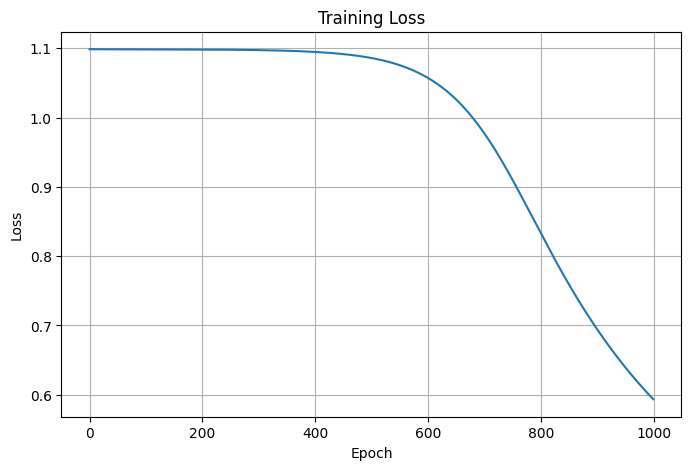

In [75]:
import matplotlib.pyplot as plt

# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

## 10. Model Testing and Evaluation

After training, the neural network is evaluated using the test dataset. The trained model predicts the class probabilities for each test sample.

The class with the highest predicted probability is selected as the final predicted class.

The model performance is evaluated using:
- Test Accuracy
- Classification Report
- Confusion Matrix

In [76]:
# Perform forward propagation on test data
Z1_test, A1_test, Z2_test, A2_test = forward_pass(
    X_test,
    W1,
    b1,
    W2,
    b2
)

# Convert predicted probabilities into class labels
y_pred = np.argmax(A2_test, axis=1)

# Display actual and predicted labels
print("Actual labels:   ", y_test)
print("Predicted labels:", y_pred)

Actual labels:    [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]
Predicted labels: [0 2 0 0 0 2 0 0 2 2 2 2 2 2 0 0 0 1 2 2 0 2 2 2 2 2 2 0 2 0]


In [77]:
# Calculate test accuracy
test_accuracy = np.mean(y_pred == y_test)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 70.00%


In [78]:
from sklearn.metrics import classification_report

# Generate classification report
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

              precision    recall  f1-score   support

      setosa       0.83      1.00      0.91        10
  versicolor       1.00      0.10      0.18        10
   virginica       0.59      1.00      0.74        10

    accuracy                           0.70        30
   macro avg       0.81      0.70      0.61        30
weighted avg       0.81      0.70      0.61        30



### Confusion Matrix

A confusion matrix is used to visualize the actual and predicted classes. It helps identify which Iris classes are correctly classified and where classification errors occur.

In [79]:
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 2  1  7]
 [ 0  0 10]]


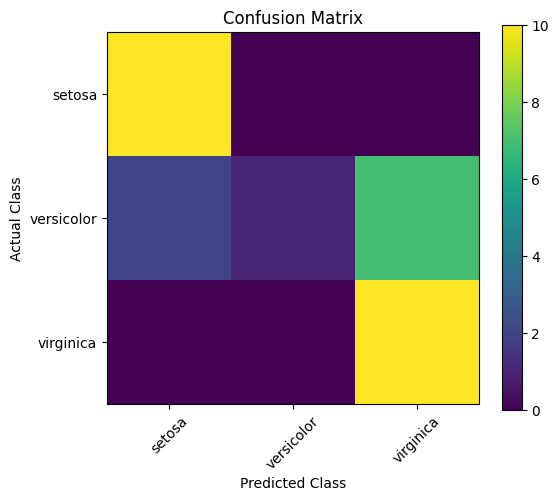

In [80]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.xticks(
    range(3),
    iris.target_names,
    rotation=45
)

plt.yticks(
    range(3),
    iris.target_names
)

plt.colorbar()

plt.show()

## 11. Results

The implemented feedforward neural network was trained on the Iris dataset using gradient descent.

The model consists of:
- 4 input neurons
- 8 hidden neurons with ReLU activation
- 3 output neurons with Softmax activation

The model performance was evaluated using test accuracy, classification report, and confusion matrix.

The training loss decreased over the epochs, indicating that the neural network successfully learned from the training data.

In [81]:
print(f"Final Training Loss: {loss_history[-1]:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Final Training Loss: 0.5935
Test Accuracy: 70.00%


## 12. Conclusion

A feedforward neural network was successfully implemented from scratch using Python and NumPy without using deep learning libraries. The implementation included forward propagation, ReLU and Softmax activation functions, categorical cross-entropy loss, backpropagation, and gradient descent.

The trained model successfully classified the Iris dataset into three different species. The decreasing training loss and test accuracy demonstrate that the neural network was able to learn the classification task effectively.

## 13. Declaration

I, **Chirag Nagawade**, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines.

The code is uploaded on my GitHub repository account, and the repository link is provided below.

**GitHub Repository Link:** https://github.com/Chirag-Nagawade/GenerativeAI-Lab-Neural-Network.git

**Signature:** Chirag Nagawade